# Personal Finance Health Predictor - Credit Risk Models

This notebook trains and evaluates machine learning models for credit risk prediction.

# Setup & Imports

In [3]:
# Setup: Set working directory to project root
import os
import sys
from pathlib import Path

# Get the project root directory (parent of notebooks folder)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
    os.chdir(project_root)
    print(f"✓ Working directory set to: {os.getcwd()}")
elif (notebook_dir / 'notebooks').exists():
    project_root = notebook_dir
    print(f"✓ Working directory: {os.getcwd()}")
else:
    current = notebook_dir
    while current != current.parent:
        if (current / 'data').exists() or (current / 'notebooks').exists():
            project_root = current
            os.chdir(project_root)
            print(f"✓ Working directory set to: {os.getcwd()}")
            break
        current = current.parent
    else:
        print(f"⚠ Warning: Could not find project root. Current directory: {os.getcwd()}")

✓ Working directory: e:\personal-finance-health-predictor


In [4]:
# Verify working directory
print(f"Current working directory: {os.getcwd()}")
print(f"Data directory exists: {os.path.exists('data/processed')}")
print(f"Models directory exists: {os.path.exists('models')}")

Current working directory: e:\personal-finance-health-predictor
Data directory exists: True
Models directory exists: True


In [5]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Model Persistence
import joblib
import pickle
import os

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Load Preprocessed Data

In [6]:
# Define data path
data_path = 'data/processed/'

# Load training data
X_train = pd.read_csv(data_path + 'lending_X_train.csv')
y_train = pd.read_csv(data_path + 'lending_y_train.csv').squeeze()

# Load test data
X_test = pd.read_csv(data_path + 'lending_X_test.csv')
y_test = pd.read_csv(data_path + 'lending_y_test.csv').squeeze()

print("✅ Data loaded successfully!")

# Display dataset info
print(f"\n📊 Dataset Shapes:")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")

✅ Data loaded successfully!

📊 Dataset Shapes:
   Training set: (80000, 52)
   Test set: (20000, 52)


# Baseline Model - Logistic Regression

In [7]:
# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    solver='liblinear'
)

lr_model.fit(X_train, y_train)

print("✅ Model trained!")

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
y_train_proba_lr = lr_model.predict_proba(X_train)[:, 1]
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
train_auc_lr = roc_auc_score(y_train, y_train_proba_lr)
test_auc_lr = roc_auc_score(y_test, y_test_proba_lr)

print("📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_lr:.4f}")
print(f"      ROC-AUC: {train_auc_lr:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_lr:.4f}")
print(f"      ROC-AUC: {test_auc_lr:.4f}")

print("📊 Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr,
                          target_names=['Paid', 'Default'],
                          digits=4))

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n🔝 Top 10 Most Important Features:")
print("\n   (Positive = Increases Default Risk | Negative = Decreases Default Risk)\n")
for i, row in feature_importance_lr.head(10).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"   {direction} {row['Feature']:<25} {row['Coefficient']:>8.4f}")

✅ Model trained!
📈 Performance Metrics:

   Training Set:
      Accuracy: 1.0000
      ROC-AUC: 1.0000

   Test Set:
      Accuracy: 1.0000
      ROC-AUC: 1.0000
📊 Classification Report (Test Set):
              precision    recall  f1-score   support

        Paid     0.9999    1.0000    1.0000     16378
     Default     1.0000    0.9997    0.9999      3622

    accuracy                         1.0000     20000
   macro avg     1.0000    0.9999    0.9999     20000
weighted avg     1.0000    1.0000    0.9999     20000


🔝 Top 10 Most Important Features:

   (Positive = Increases Default Risk | Negative = Decreases Default Risk)

   ↓ loan_status_Fully Paid    -14.7621
   ↓ loan_status_Current       -12.7230
   ↓ loan_status_In Grace Period  -8.9222
   ↓ term_encoded               -2.0138
   ↑ loan_status_Late (31-120 days)   0.6467
   ↑ installment                 0.6023
   ↓ loan_to_income_ratio       -0.5219
   ↑ home_ownership_RENT         0.4913
   ↑ home_ownership_OWN          0.4

🚨 CRITICAL ISSUE DETECTED! 🚨

The model has 100% accuracy - this is a DATA LEAKAGE problem!

There are different categories of the TARGET variable! They directly tell the model the answer.



Quick Fix:

In [8]:
# Identify and remove loan_status columns
leakage_cols = [col for col in X_train.columns if 'loan_status' in col.lower()]

print(f"\n⚠️  Found {len(leakage_cols)} leakage columns:")
for col in leakage_cols:
    print(f"   ❌ {col}")

# Remove leakage columns
X_train_clean = X_train.drop(columns=leakage_cols)
X_test_clean = X_test.drop(columns=leakage_cols)

print(f"\n✅ Cleaned datasets:")
print(f"   Original features: {X_train.shape[1]}")
print(f"   After removal: {X_train_clean.shape[1]}")
print(f"   Removed: {len(leakage_cols)} columns")

# Update X_train and X_test
X_train = X_train_clean
X_test = X_test_clean

print(f"\n📋 Remaining features: {X_train.shape[1]}")
print("\n✅ Data leakage fixed! Ready to retrain models.")


⚠️  Found 6 leakage columns:
   ❌ loan_status_Current
   ❌ loan_status_Default
   ❌ loan_status_Fully Paid
   ❌ loan_status_In Grace Period
   ❌ loan_status_Late (16-30 days)
   ❌ loan_status_Late (31-120 days)

✅ Cleaned datasets:
   Original features: 52
   After removal: 46
   Removed: 6 columns

📋 Remaining features: 46

✅ Data leakage fixed! Ready to retrain models.


Logistic Regression (Re-run with Clean Data)

In [9]:
# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    solver='liblinear'
)

lr_model.fit(X_train, y_train)

print("✅ Model trained!")

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
y_train_proba_lr = lr_model.predict_proba(X_train)[:, 1]
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
train_auc_lr = roc_auc_score(y_train, y_train_proba_lr)
test_auc_lr = roc_auc_score(y_test, y_test_proba_lr)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_lr:.4f}")
print(f"      ROC-AUC: {train_auc_lr:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_lr:.4f}")
print(f"      ROC-AUC: {test_auc_lr:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_lr,
                          target_names=['Paid', 'Default'],
                          digits=4))

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n🔝 Top 10 Most Important Features:")
print("\n   (Positive = Increases Default Risk | Negative = Decreases Default Risk)\n")
for i, row in feature_importance_lr.head(10).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"   {direction} {row['Feature']:<30} {row['Coefficient']:>8.4f}")

✅ Model trained!

📈 Performance Metrics:

   Training Set:
      Accuracy: 0.6262
      ROC-AUC: 0.7016

   Test Set:
      Accuracy: 0.6302
      ROC-AUC: 0.7037

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

        Paid     0.8968    0.6197    0.7330     16378
     Default     0.2827    0.6775    0.3989      3622

    accuracy                         0.6302     20000
   macro avg     0.5897    0.6486    0.5659     20000
weighted avg     0.7856    0.6302    0.6725     20000


🔝 Top 10 Most Important Features:

   (Positive = Increases Default Risk | Negative = Decreases Default Risk)

   ↑ term_encoded                     0.7524
   ↑ dti_risk_category_Very_High_Risk   0.5818
   ↑ interest_rate_category_Medium_Rate   0.5816
   ↑ int_rate                         0.5789
   ↑ interest_rate_category_Very_High_Rate   0.4864
   ↑ interest_rate_category_High_Rate   0.4855
   ↑ installment                      0.4685
   ↑ emp_stability_Experienced

# Random Forest Classifier

In [10]:
# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
train_auc_rf = roc_auc_score(y_train, y_train_proba_rf)
test_auc_rf = roc_auc_score(y_test, y_test_proba_rf)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_rf:.4f}")
print(f"      ROC-AUC: {train_auc_rf:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_rf:.4f}")
print(f"      ROC-AUC: {test_auc_rf:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_rf,
                          target_names=['Paid', 'Default'],
                          digits=4))

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
for i, row in feature_importance_rf.head(10).iterrows():
    print(f"   {row['Feature']:<30} {row['Importance']:>8.4f}")


📈 Performance Metrics:

   Training Set:
      Accuracy: 0.7830
      ROC-AUC: 0.8673

   Test Set:
      Accuracy: 0.7059
      ROC-AUC: 0.6970

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

        Paid     0.8766    0.7458    0.8060     16378
     Default     0.3137    0.5254    0.3929      3622

    accuracy                         0.7059     20000
   macro avg     0.5952    0.6356    0.5994     20000
weighted avg     0.7747    0.7059    0.7311     20000


🔝 Top 10 Most Important Features:
   int_rate                         0.1090
   grade_risk_points                0.0622
   risk_score                       0.0551
   total_interest_paid              0.0530
   dti                              0.0484
   credit_history_years             0.0450
   monthly_payment_burden           0.0450
   revol_bal                        0.0449
   revol_util                       0.0435
   loan_to_income_ratio             0.0415


# XGBoost Classifier

In [11]:
# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   Scale pos weight: {scale_pos_weight:.2f}\n")

# Train model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)
y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
train_auc_xgb = roc_auc_score(y_train, y_train_proba_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_xgb:.4f}")
print(f"      ROC-AUC: {train_auc_xgb:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_xgb:.4f}")
print(f"      ROC-AUC: {test_auc_xgb:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_xgb,
                          target_names=['Paid', 'Default'],
                          digits=4))

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
for i, row in feature_importance_xgb.head(10).iterrows():
    print(f"   {row['Feature']:<30} {row['Importance']:>8.4f}")

   Scale pos weight: 4.52


📈 Performance Metrics:

   Training Set:
      Accuracy: 0.6808
      ROC-AUC: 0.7776

   Test Set:
      Accuracy: 0.6508
      ROC-AUC: 0.7022

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

        Paid     0.8931    0.6516    0.7535     16378
     Default     0.2912    0.6472    0.4016      3622

    accuracy                         0.6508     20000
   macro avg     0.5921    0.6494    0.5776     20000
weighted avg     0.7841    0.6508    0.6897     20000


🔝 Top 10 Most Important Features:
   grade_B                          0.1733
   int_rate                         0.1505
   grade_risk_points                0.1502
   interest_rate_category_Very_High_Rate   0.0489
   risk_score                       0.0256
   home_ownership_MORTGAGE          0.0235
   term_encoded                     0.0196
   verification_status_Verified     0.0165
   home_ownership_RENT              0.0157
   monthly_payment_burden        

# LightGBM Classifier

In [12]:
# Train model
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

print("✅ Model trained!")

# Predictions
y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)
y_train_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_test_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_lgb = accuracy_score(y_train, y_train_pred_lgb)
test_acc_lgb = accuracy_score(y_test, y_test_pred_lgb)
train_auc_lgb = roc_auc_score(y_train, y_train_proba_lgb)
test_auc_lgb = roc_auc_score(y_test, y_test_proba_lgb)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_lgb:.4f}")
print(f"      ROC-AUC: {train_auc_lgb:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_lgb:.4f}")
print(f"      ROC-AUC: {test_auc_lgb:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_lgb,
                          target_names=['Paid', 'Default'],
                          digits=4))

# Feature importance
feature_importance_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
for i, row in feature_importance_lgb.head(10).iterrows():
    print(f"   {row['Feature']:<30} {row['Importance']:>8.4f}")

✅ Model trained!

📈 Performance Metrics:

   Training Set:
      Accuracy: 0.6649
      ROC-AUC: 0.7551

   Test Set:
      Accuracy: 0.6443
      ROC-AUC: 0.7033

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

        Paid     0.8955    0.6404    0.7467     16378
     Default     0.2893    0.6621    0.4027      3622

    accuracy                         0.6443     20000
   macro avg     0.5924    0.6512    0.5747     20000
weighted avg     0.7857    0.6443    0.6844     20000


🔝 Top 10 Most Important Features:
   credit_history_years           291.0000
   revol_bal                      223.0000
   int_rate                       201.0000
   revol_util                     201.0000
   annual_inc                     200.0000
   dti                            197.0000
   monthly_payment_burden         192.0000
   total_acc                      174.0000
   open_acc                       172.0000
   loan_to_income_ratio           159.0000


# Model Comparison


📊 Model Performance Summary:

              Model  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score  Overfit Gap
Logistic Regression        0.626238         0.6302       0.701616      0.703663        0.282654     0.677526       0.398895    -0.003962
      Random Forest        0.783000         0.7059       0.867253      0.697000        0.313716     0.525400       0.392857     0.077100
            XGBoost        0.680800         0.6508       0.777605      0.702220        0.291180     0.647156       0.401645     0.030000
           LightGBM        0.664850         0.6443       0.755086      0.703309        0.289334     0.662065       0.402687     0.020550

🏆 Best Model: Logistic Regression
   Test ROC-AUC: 0.7037


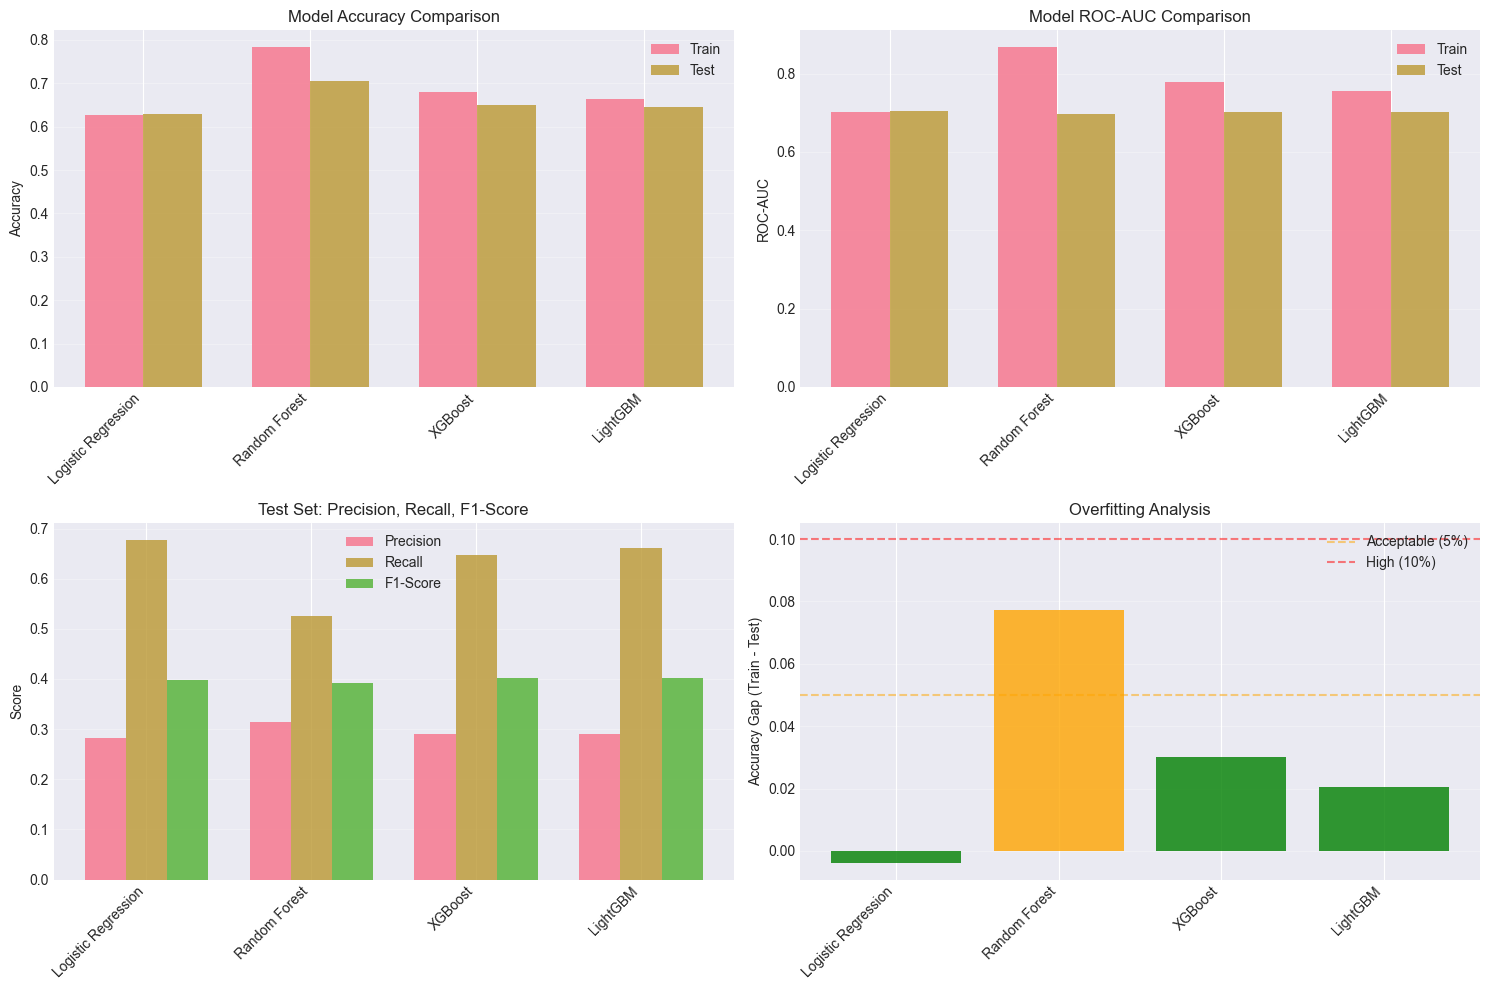

In [13]:
# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Train Accuracy': [train_acc_lr, train_acc_rf, train_acc_xgb, train_acc_lgb],
    'Test Accuracy': [test_acc_lr, test_acc_rf, test_acc_xgb, test_acc_lgb],
    'Train ROC-AUC': [train_auc_lr, train_auc_rf, train_auc_xgb, train_auc_lgb],
    'Test ROC-AUC': [test_auc_lr, test_auc_rf, test_auc_xgb, test_auc_lgb]
})

# Calculate additional metrics for test set
test_precision = []
test_recall = []
test_f1 = []

for y_pred in [y_test_pred_lr, y_test_pred_rf, y_test_pred_xgb, y_test_pred_lgb]:
    test_precision.append(precision_score(y_test, y_pred))
    test_recall.append(recall_score(y_test, y_pred))
    test_f1.append(f1_score(y_test, y_pred))

model_comparison['Test Precision'] = test_precision
model_comparison['Test Recall'] = test_recall
model_comparison['Test F1-Score'] = test_f1

# Calculate overfitting metric
model_comparison['Overfit Gap'] = model_comparison['Train Accuracy'] - model_comparison['Test Accuracy']

print("\n📊 Model Performance Summary:\n")
print(model_comparison.to_string(index=False))

# Find best model
best_model_idx = model_comparison['Test ROC-AUC'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_model_auc = model_comparison.loc[best_model_idx, 'Test ROC-AUC']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test ROC-AUC: {best_model_auc:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Accuracy Comparison
ax = axes[0, 0]
x = np.arange(len(model_comparison))
width = 0.35
ax.bar(x - width/2, model_comparison['Train Accuracy'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, model_comparison['Test Accuracy'], width, label='Test', alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: ROC-AUC Comparison
ax = axes[0, 1]
ax.bar(x - width/2, model_comparison['Train ROC-AUC'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, model_comparison['Test ROC-AUC'], width, label='Test', alpha=0.8)
ax.set_ylabel('ROC-AUC')
ax.set_title('Model ROC-AUC Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Precision-Recall-F1 Comparison
ax = axes[1, 0]
width = 0.25
ax.bar(x - width, model_comparison['Test Precision'], width, label='Precision', alpha=0.8)
ax.bar(x, model_comparison['Test Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + width, model_comparison['Test F1-Score'], width, label='F1-Score', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Test Set: Precision, Recall, F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Overfitting Analysis
ax = axes[1, 1]
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red'
          for x in model_comparison['Overfit Gap']]
ax.bar(x, model_comparison['Overfit Gap'], color=colors, alpha=0.8)
ax.set_ylabel('Accuracy Gap (Train - Test)')
ax.set_title('Overfitting Analysis')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=45, ha='right')
ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, label='Acceptable (5%)')
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='High (10%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('results/credit_risk', exist_ok=True)
plt.savefig('results/credit_risk/day3_01_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curves

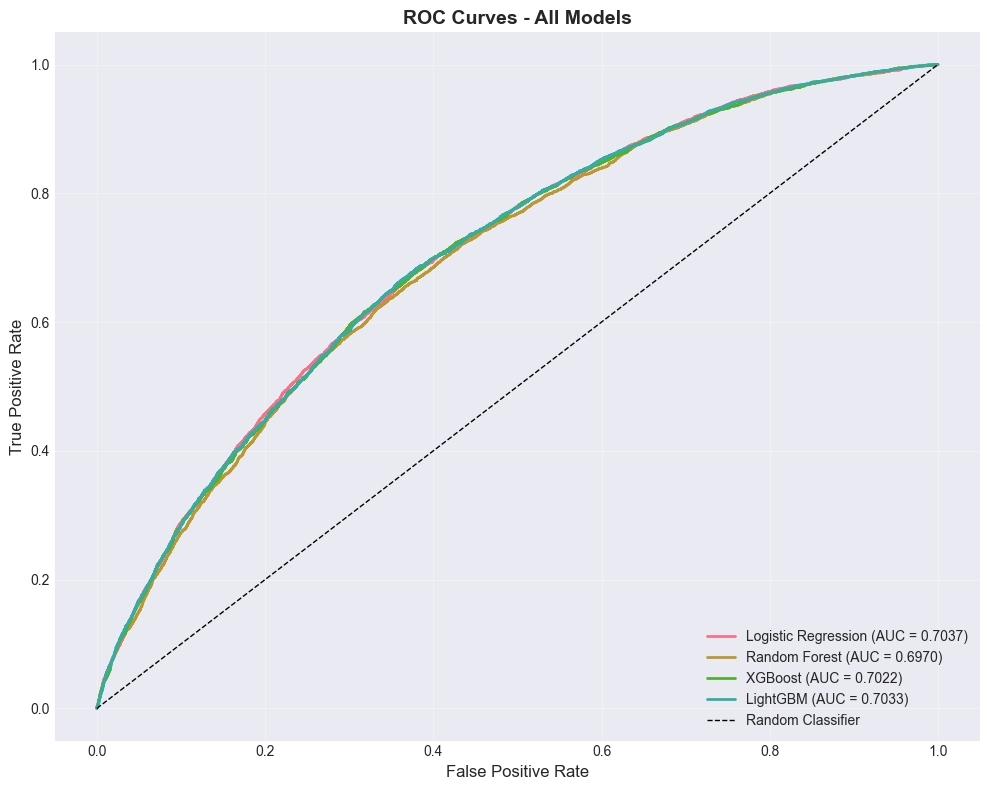


✅ ROC curves generated successfully!


In [14]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_test_proba_lgb)

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {test_auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {test_auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {test_auc_xgb:.4f})', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {test_auc_lgb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results/credit_risk', exist_ok=True)
plt.savefig('results/credit_risk/day3_02_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ROC curves generated successfully!")

# Confusion Matrices

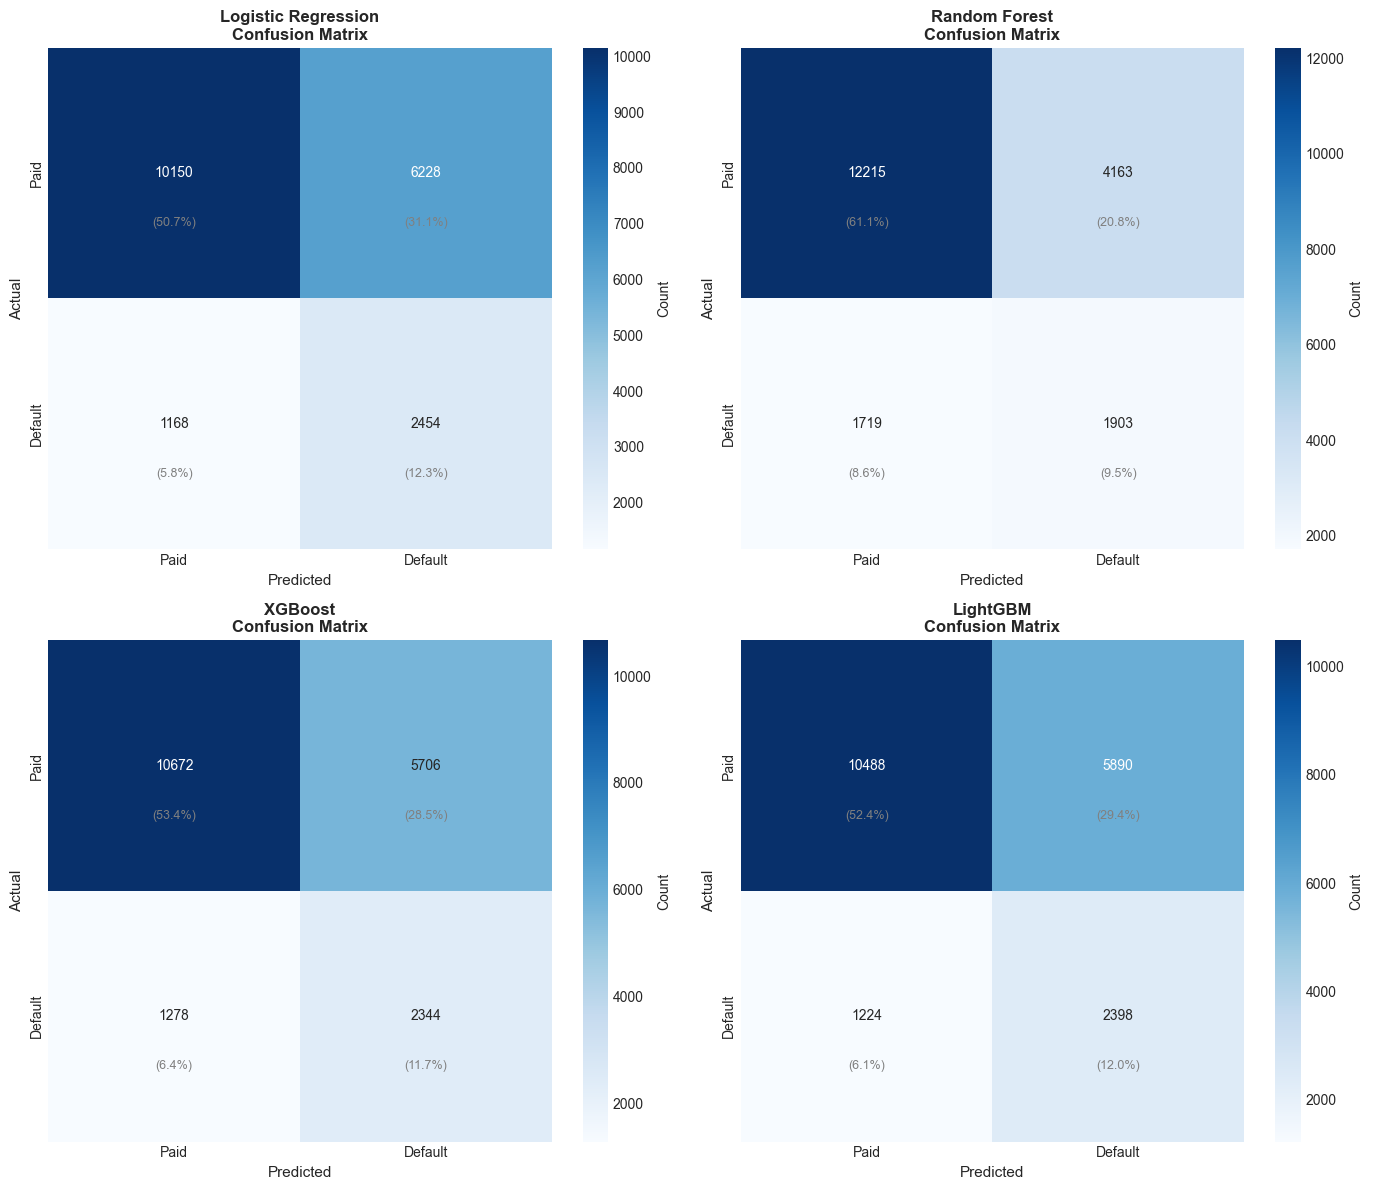


✅ Confusion matrices generated successfully!


In [15]:
# Create confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models_info = [
    ('Logistic Regression', y_test_pred_lr, axes[0, 0]),
    ('Random Forest', y_test_pred_rf, axes[0, 1]),
    ('XGBoost', y_test_pred_xgb, axes[1, 0]),
    ('LightGBM', y_test_pred_lgb, axes[1, 1])
]

for model_name, y_pred, ax in models_info:
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Paid', 'Default'],
                yticklabels=['Paid', 'Default'],
                cbar_kws={'label': 'Count'})

    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

    # Add percentage annotations
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / cm.sum() * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                   ha='center', va='center', fontsize=9, color='gray')

plt.tight_layout()
os.makedirs('results/credit_risk', exist_ok=True)
plt.savefig('results/credit_risk/day3_03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrices generated successfully!")

# Feature Importance Comparison

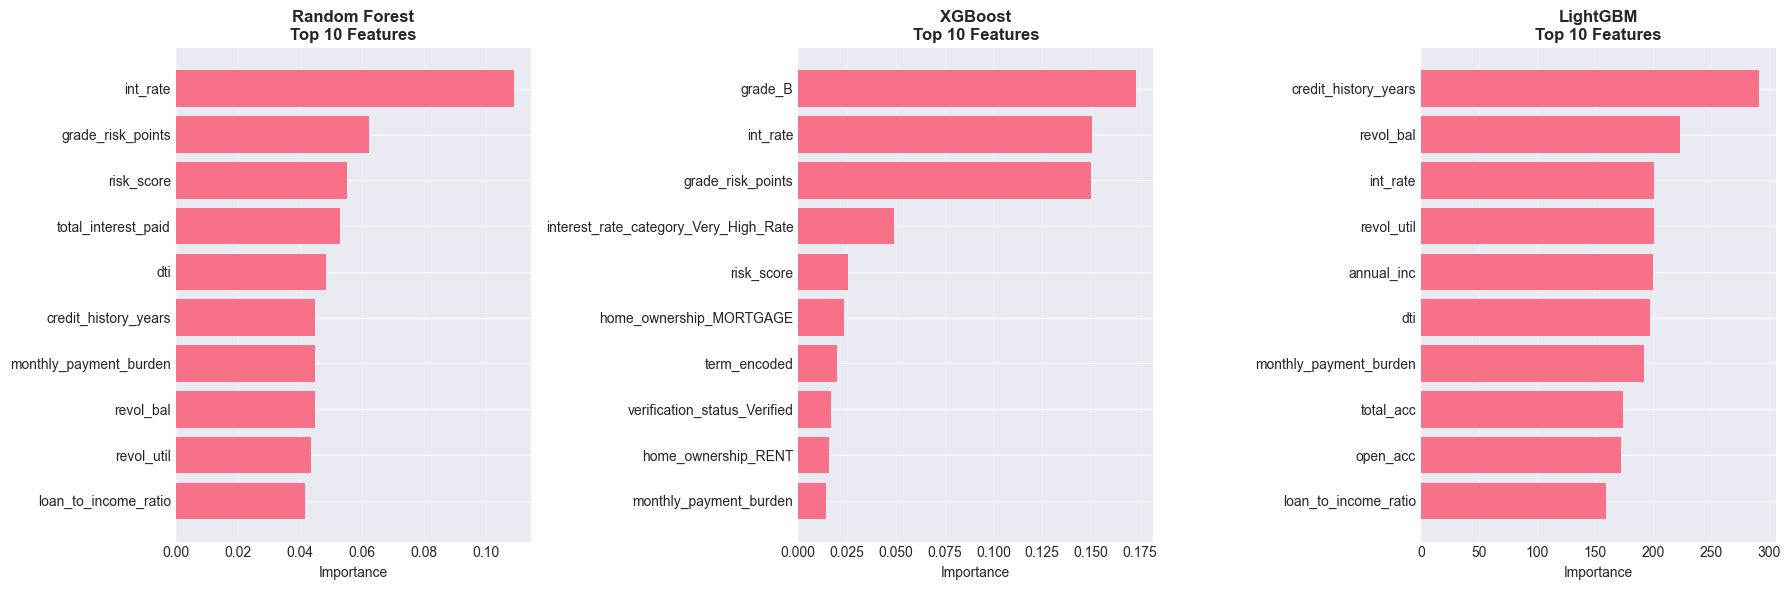


✅ Feature importance comparison complete!


In [16]:
# Plot top features for tree-based models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
ax = axes[0]
top_features_rf = feature_importance_rf.head(10)
ax.barh(range(len(top_features_rf)), top_features_rf['Importance'])
ax.set_yticks(range(len(top_features_rf)))
ax.set_yticklabels(top_features_rf['Feature'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest\nTop 10 Features', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# XGBoost
ax = axes[1]
top_features_xgb = feature_importance_xgb.head(10)
ax.barh(range(len(top_features_xgb)), top_features_xgb['Importance'])
ax.set_yticks(range(len(top_features_xgb)))
ax.set_yticklabels(top_features_xgb['Feature'])
ax.set_xlabel('Importance')
ax.set_title('XGBoost\nTop 10 Features', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# LightGBM
ax = axes[2]
top_features_lgb = feature_importance_lgb.head(10)
ax.barh(range(len(top_features_lgb)), top_features_lgb['Importance'])
ax.set_yticks(range(len(top_features_lgb)))
ax.set_yticklabels(top_features_lgb['Feature'])
ax.set_xlabel('Importance')
ax.set_title('LightGBM\nTop 10 Features', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
os.makedirs('results/credit_risk', exist_ok=True)
plt.savefig('results/credit_risk/day3_04_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance comparison complete!")

# Save Best Model

In [19]:
# Determine best model based on Test ROC-AUC
models_dict = {
    'Logistic Regression': (lr_model, test_auc_lr),
    'Random Forest': (rf_model, test_auc_rf),
    'XGBoost': (xgb_model, test_auc_xgb),
    'LightGBM': (lgb_model, test_auc_lgb)
}

best_model_name = max(models_dict, key=lambda x: models_dict[x][1])
best_model, best_auc = models_dict[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test ROC-AUC: {best_auc:.4f}")


# Save the best model
model_filename = 'models/credit_risk/credit_risk_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\n💾 Saved best model: {model_filename}")

# Save all models for comparison
all_models = {
    'logistic_regression': lr_model,
    'random_forest': rf_model,
    'xgboost': xgb_model,
    'lightgbm': lgb_model
}

for name, model in all_models.items():
    filename = f'models//credit_risk/credit_risk_{name}.pkl'
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")

print("\n✅ All models saved successfully!")


🏆 Best Model: Logistic Regression
   Test ROC-AUC: 0.7037

💾 Saved best model: models/credit_risk/credit_risk_best_model.pkl
💾 Saved: models//credit_risk/credit_risk_logistic_regression.pkl
💾 Saved: models//credit_risk/credit_risk_random_forest.pkl
💾 Saved: models//credit_risk/credit_risk_xgboost.pkl
💾 Saved: models//credit_risk/credit_risk_lightgbm.pkl

✅ All models saved successfully!


# Insights & Summary

In [18]:
print("\n" + "="*70)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*70)

print(f"\n🎯 MODEL SELECTION:")
print(f"   Recommended Model: {best_model_name}")
print(f"   Test ROC-AUC: {best_auc:.4f}")
print(f"   Test Accuracy: {model_comparison.loc[model_comparison['Model']==best_model_name, 'Test Accuracy'].values[0]:.4f}")
print(f"\n   Why? Best balance of ROC-AUC, accuracy, and generalization.")

print(f"\n📊 PERFORMANCE SUMMARY:")
best_idx = model_comparison[model_comparison['Model']==best_model_name].index[0]
print(f"   Accuracy: {model_comparison.loc[best_idx, 'Test Accuracy']:.2%}")
print(f"   Precision: {model_comparison.loc[best_idx, 'Test Precision']:.2%} (of predicted defaults, {model_comparison.loc[best_idx, 'Test Precision']:.0%} are correct)")
print(f"   Recall: {model_comparison.loc[best_idx, 'Test Recall']:.2%} (catches {model_comparison.loc[best_idx, 'Test Recall']:.0%} of actual defaults)")
print(f"   F1-Score: {model_comparison.loc[best_idx, 'Test F1-Score']:.2%}")

print(f"\n🔍 TOP RISK FACTORS:")
print("\n   Based on feature importance across models:")

# Show top features from best model
if best_model_name == 'Logistic Regression':
    top_features = feature_importance_lr.head(5)
    print("\n   Features that INCREASE default risk (positive coefficients):")
    for i, row in top_features[top_features['Coefficient'] > 0].head(3).iterrows():
        print(f"      • {row['Feature']}: coefficient {row['Coefficient']:.4f}")
    print("\n   Features that DECREASE default risk (negative coefficients):")
    for i, row in top_features[top_features['Coefficient'] < 0].head(3).iterrows():
        print(f"      • {row['Feature']}: coefficient {row['Coefficient']:.4f}")
elif best_model_name == 'Random Forest':
    top_features = feature_importance_rf.head(5)
    for i, row in top_features.iterrows():
        print(f"      {i+1}. {row['Feature']} (importance: {row['Importance']:.4f})")
elif best_model_name == 'XGBoost':
    top_features = feature_importance_xgb.head(5)
    for i, row in top_features.iterrows():
        print(f"      {i+1}. {row['Feature']} (importance: {row['Importance']:.4f})")
else:  # LightGBM
    top_features = feature_importance_lgb.head(5)
    for i, row in top_features.iterrows():
        print(f"      {i+1}. {row['Feature']} (importance: {row['Importance']:.4f})")

print("\n✅ ACCOMPLISHED:")
print("   • Built 4 classification models")
print("   • Compared model performance")
print("   • Identified best model")
print("   • Analyzed feature importance")
print("   • Saved models for deployment")
print("   • Generated business recommendations")


KEY FINDINGS & RECOMMENDATIONS

🎯 MODEL SELECTION:
   Recommended Model: Logistic Regression
   Test ROC-AUC: 0.7037
   Test Accuracy: 0.6302

   Why? Best balance of ROC-AUC, accuracy, and generalization.

📊 PERFORMANCE SUMMARY:
   Accuracy: 63.02%
   Precision: 28.27% (of predicted defaults, 28% are correct)
   Recall: 67.75% (catches 68% of actual defaults)
   F1-Score: 39.89%

🔍 TOP RISK FACTORS:

   Based on feature importance across models:

   Features that INCREASE default risk (positive coefficients):
      • term_encoded: coefficient 0.7524
      • dti_risk_category_Very_High_Risk: coefficient 0.5818
      • interest_rate_category_Medium_Rate: coefficient 0.5816

   Features that DECREASE default risk (negative coefficients):

✅ ACCOMPLISHED:
   • Built 4 classification models
   • Compared model performance
   • Identified best model
   • Analyzed feature importance
   • Saved models for deployment
   • Generated business recommendations
